# 4.26

$$ \epsilon_n = E_n - E_c $$

$$ \epsilon_n = \frac{h^2 n^2}{8m_e^* d^2}$$

where n is the quantum number

Additionally,
$$ \epsilon_{n'} = E_{n'} - E_c $$

$$ \epsilon_{n'} = \frac{h^2 n'^2}{8m_h^* d^2}$$

In [1]:
import numpy as np
from scipy.constants import h, e

d = 10e-9
m_star_e = 0.04*9.1*10**-31
m_star_h = 0.44*9.1*10**-31

n= np.array([1, 2])
n_prime = np.array([1])

epsilon_n = h**2 * n**2 / (8*m_star_e * d**2) / e
epsilon_n_prime = h**2 * n_prime**2 / (8*m_star_h * d**2) / e

print("First and Second Energy Levels Above Conduction Band")
for _n, _epsilon_n in zip(n, epsilon_n):
    print(f"ε_{_n} = {_epsilon_n} eV")

print()
print("First Energy Level Below Valence Band")
for _n_prime, _epsilon_n_prime in zip(n_prime, epsilon_n_prime):
    print(f"ε_{_n_prime}' = {_epsilon_n_prime} eV")

First and Second Energy Levels Above Conduction Band
ε_1 = 0.09410447897289292 eV
ε_2 = 0.3764179158915717 eV

First Energy Level Below Valence Band
ε_1' = 0.008554952633899358 eV


For Quantum Wells, we must obey the selection rules:  
$$ \Delta n = n' - n = 0 $$

which implies radiative transition is from $\epsilon_1$ to $\epsilon_1'$ is  
$$ \lambda_{QW} = \frac{hc}{E_g + \epsilon_1 + \epsilon_1 '} $$

In [2]:
epsilon_1 = epsilon_n[np.where(n==1)[0][0]]
epsilon_1_prime = epsilon_n_prime[np.where(n_prime==1)[0][0]]


In [3]:
from scipy.constants import c

E_g = 0.7 # eV
lam_QW = h*c / (e*(E_g + epsilon_1 + epsilon_1_prime))

print(f"Lasing Emission Wavelength for this SQW laser:")
print(f"λ_QW = {lam_QW:e}")

Lasing Emission Wavelength for this SQW laser:
λ_QW = 1.544668e-06


In [4]:
print(f"Wavelgenth if this transition were to occur in bulk InGaAs: ")
lam_bulk = h*c / (e*(E_g))
print(f"λ_bulk = {lam_bulk:e}")

Wavelgenth if this transition were to occur in bulk InGaAs: 
λ_bulk = 1.771203e-06


# 4.27

$$ \Gamma g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1 R_2}) $$

Because no information is given about the refractive indices of the cladding regions, we may assume

$$ \Gamma = 1 $$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1 R_2}) $$

Since we know how the refractive index changes with temperature, we will rewrite the gain equation in terms of the refractive index, and then in terms of temperature. We also assume that $R_1 = R_2 = \frac{(n - 1)^2}{(n+1)^2}$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{1}{R_1^2}) = \alpha_s + \frac{1}{2L}ln(\frac{(n+1)^4}{(n - 1)^4}) $$

We are only told the first derivative of $n$ with respect to temperature, so we will assume it can be approximated as linear.  

$$ n = n_{ambient} +\frac{dn}{dT}\Delta T $$
$$ n = n_0 + \frac{dn}{dT}\Delta T $$

$$ g_{th} = \alpha_s + \frac{1}{2L}ln(\frac{(n_0 + 1 + \frac{dn}{dT}\Delta T)^4}{(n_0 - 1 \frac{dn}{dT}\Delta T)^4}) $$

The dimensions of linear expansion are $\frac{[\Delta L \space microns]}{[L \space meters][\Delta T]}$, and since we know the length of the cavity at ambient temperature, we can express  
$$L = L_{ambient}( 1 + \alpha_L \Delta T) $$
$$ L = (1 + \alpha_T \Delta T) \times 200\space \mu m  $$

$$ g_{th} = \alpha_s + \frac{1}{2(1 + \alpha_T \Delta T) \times L_0}ln(\frac{(n_0 + 1 + \frac{dn}{dT}\Delta T)^4}{(n_0 - 1 + \frac{dn}{dT}\Delta T)^4}) $$

We simply need to evaluated the derivative at 300 K, or when $\Delta T$ is zero. Applying the product rule we get.  

$$\frac{d g_{th}}{dT} = \frac{1}{2L_0} \frac{d}{dT}[ln(\frac{(n_0 + 1 + \frac{dn}{dT}(T-300))^4}{(n_0 - 1 + \frac{dn}{dT}(T-300))^4})] +  \frac{d}{dT}[(2(1+\alpha_L(T-300))L_0)^{-1}]ln(\frac{(n_0 + 1)^4}{(n_0 - 1)^4})$$

Applying the chain rule we obtain:  

$$\frac{d g_{th}}{dT} = \frac{1}{2L_0} \frac{(n_0 - 1)^4}{(n_0 + 1)^4}[\frac{4\frac{dn}{dT}(n_0-1)^4(n_0+1)^3 - 4\frac{dn}{dT}(n_0-1)^3(n_0+1)^4}{(n_0-1)^8}] +  \frac{d}{dT}[(2(1+\alpha_L(T-300))L_0)^{-1}]ln((\frac{n_0 + 1}{n_0 - 1})^4)$$


$$\frac{d g_{th}}{dT} = \frac{4\frac{dn}{dT}}{2L_0} [\frac{(n_0-1) - (n_0+1)}{(n_0-1)(n_0 + 1)}] +  \frac{d}{dT}[(2(1+\alpha_L(T-300))L_0)^{-1}]ln((\frac{n_0 + 1}{n_0 - 1})^4)$$

$$\frac{d g_{th}}{dT} = \frac{4\frac{dn}{dT}}{2L_0} [\frac{(n_0-1) - (n_0+1)}{(n_0-1)(n_0 + 1)}] - (2(1+\alpha_L(T-300))L_0)^{-2} 2 \alpha_L L_0 ln((\frac{n_0 + 1}{n_0 - 1})^4)$$

$$\frac{d g_{th}}{dT} = \frac{4\frac{dn}{dT}}{2L_0} [\frac{(n_0-1) - (n_0+1)}{(n_0-1)(n_0 + 1)}] - 2 (2L_0)^{-2} \alpha_L L_0 ln((\frac{n_0 + 1}{n_0 - 1})^4)$$

$$\frac{d g_{th}(T=300)}{dT} = \frac{2\frac{dn}{dT}}{L_0} [\frac{(n_0-1) - (n_0+1)}{(n_0-1)(n_0 + 1)}] -  \frac{\alpha_L}{2 L_0} ln((\frac{n_0 + 1}{n_0 - 1})^4)$$

dg_dT = -0.2931189380874427 K^-1


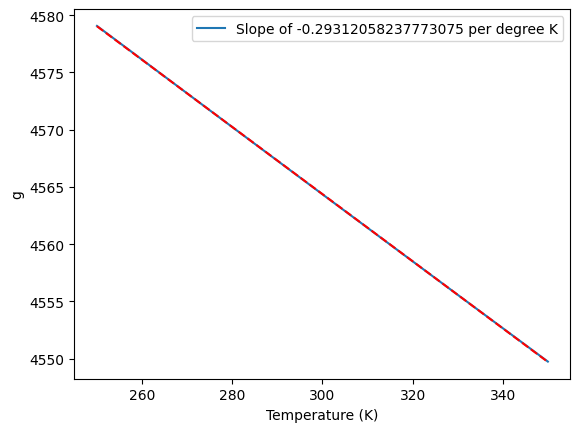

In [5]:
lam = 1550e-9
L_0 = 250e-6
alpha_s = 0.0
n_room_temp = 3.60 # refractive index, at room temperature I think
n_0 = n_room_temp
dn_dT = 2e-4 # K^-1
linear_thermal_expansion = 5.6e-6 # K^-1
alpha_L = linear_thermal_expansion
E_go = 0.850 # eV
A = 4.906e-4 # eV
B = 301 # K

import matplotlib.pyplot as plt

# print( 
#     (4*dn_dT * ((n_room_temp-1)**4 - (n_room_temp+1)**4)/((n_room_temp+1)*(n_room_temp-1)) - np.log((n_room_temp+1)**4/(n_room_temp-1)**4)*linear_thermal_expansion)/(2*L)
# )


dg_dT = (1/(2*L_0)) * (n_room_temp - 1)**4 / (n_room_temp + 1)**4 * ((n_room_temp-1)**4 * 4*(n_room_temp+1)**3 * dn_dT - (n_room_temp+1)**4 * 4*(n_room_temp-1)**3 * dn_dT)/(n_room_temp-1)**8 -linear_thermal_expansion*np.log((n_room_temp+1)**4 / (n_room_temp - 1)**4) / (2*L_0)

dg_dT = 2*dn_dT / L_0 * ((n_0 - 1)-(n_0 + 1))/((n_0 - 1)*(n_0 + 1)) - alpha_L / (2 * L_0)*np.log(((n_0 + 1)/(n_0 -1))**4)
print( 
    f"dg_dT = {dg_dT} K^-1"    
)

# print( 
#     (1/(2*L)) * (n_room_temp - 1)**4 / (n_room_temp + 1)**4 * ((n_room_temp-1)**4 * 4*(n_room_temp+1)**3 * dn_dT - (n_room_temp+1)**4 * 4*(n_room_temp-1)**3 * dn_dT)/(n_room_temp-1)**8
# )

# print(-linear_thermal_expansion*np.log((n_room_temp+1)**4 / (n_room_temp - 1)**4) / (2*L))

T = np.linspace(250, 350, 1000)
alpha_T = 5.6*10**-6
n = n_room_temp - dn_dT*(300 - T)
L = (1 + alpha_T * (T-300)) * L_0
# plt.plot(T, n)

R = (n-1)**2 / (n+1)**2 # Assuming that this is at 
# x = 1/R**2
# plt.plot(x, np.log(1/R**2))
# plt.plot(x, 0.104*x + 1.26)

# plt.show()
g = 1/(2*L) * np.log(1/R**2)

slope, intercept = np.polyfit(T, g, deg=1)

plt.plot(T, g, label=f"Slope of {slope} per degree K")
plt.plot(T, T*slope+intercept, "r--")
plt.xlabel("Temperature (K)")
plt.ylabel("g")
plt.legend()
plt.show()



Next, we must find how emission wavelength for a given mode changes per unit temperature change.

for a given mode the emission frequency is
$$ \nu_m = \frac{mc}{2nL} $$
Where m is an integer indicating the mode number
$$ \lambda_m = \frac{c}{\nu_m} = \frac{2nL}{m} $$
$$ \frac{d\lambda_m}{dT} = \frac{d}{dT}[\frac{2nL}{m}] $$

$$ \frac{d\lambda_m}{dT} = \frac{d}{dT}[\frac{2(n_0 + \frac{dn}{dT}\Delta T)(L_{0}( 1 + \alpha_L \Delta T))}{m}] $$

$$ \frac{d\lambda_m}{dT} = \frac{2}{m}\frac{d}{dT}[(n_0 + \frac{dn}{dT}\Delta T)(L_{0}( 1 + \alpha_L \Delta T))] $$

$$ \frac{d\lambda_m}{dT} = \frac{2}{m}[(n_0 + \frac{dn}{dT}\Delta T)\frac{d}{dT}[L_{0}( 1 + \alpha_L \Delta T)] + \frac{d}{dT}[n_0 + \frac{dn}{dT}\Delta T](L_{0}( 1 + \alpha_L \Delta T))] $$

$$ \frac{d\lambda_m}{dT} = \frac{2}{m}(n_0\frac{d}{dT}[L_{0}( 1 + \alpha_L (T-300))] + L_{0}\frac{d}{dT}[n_0 + \frac{dn}{dT}(T-300)]) $$

$$ \frac{d\lambda_m}{dT} = \frac{2}{m}(n_0L_{0}\alpha_L + L_{0}\frac{dn}{dT}) $$

$$ \frac{d\lambda_m(T=300)}{dT} = \frac{2L_{0}}{m}(n_0\alpha_L + \frac{dn}{dT}) $$

1.1007999999999938e-13
1.1008000000000001e-13


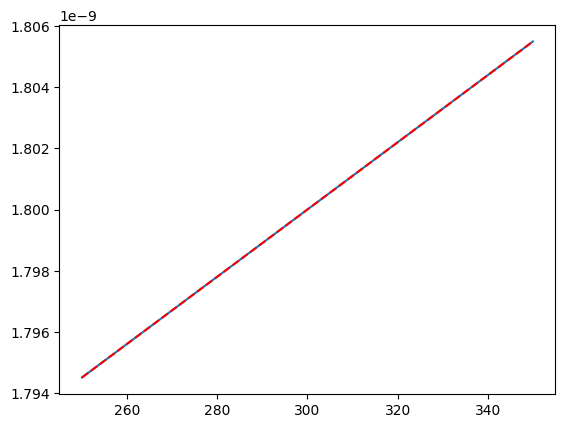

In [6]:
m = 1e6

lam = 2*n*L / m

slope, intercept = np.polyfit(T, lam, deg=1)
plt.plot(T, lam)
plt.plot(T, slope*T + intercept, "r--")

print(slope)
dlam_m_dT = 2*L_0/m*(n_0*alpha_L + dn_dT)
print(dlam_m_dT)

Without reference to the specific mode number we continue
$$ \lambda = \frac{c}{\nu} $$

We can rewrite $\nu$ in terms of the bandgap  

$$ \nu = \frac{E_g}{h} $$
$$ \lambda = \frac{hc}{E_g} = \frac{hc}{E_{go} - AT^2/(B+T)}$$

Taking the derivative  
$$ \frac{d\lambda}{dT} = -\frac{hc}{(qE_{go} - qAT^2/(B+T))^2 }\times \frac{q2AT(B+T) - qAT^2}{(B+T)^2}$$
$$ \frac{d\lambda}{dT} = -\frac{hc}{q(E_{go} - AT^2/(B+T))^2 }\times \frac{2ATB+AT^2}{(B+T)^2}$$
$$ \frac{d\lambda}{dT} = -\frac{hc}{q(E_{go} - AT^2/(B+T))^2 }\times  \frac{2ATB+AT^2}{(B+T)^2}$$

7.555041880985263e-10
-7.557071261468189e-10


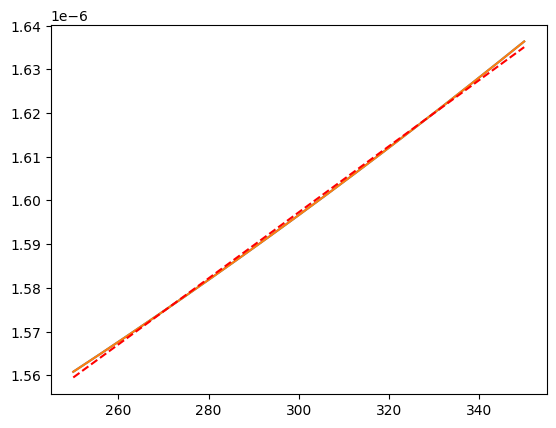

In [7]:
E_g = e*(E_go - A*T**2 / (B+T))
f = (E_g) / h
lam = c / f

slope, intercept = np.polyfit(T, lam, deg=1)
plt.plot(T, lam)
plt.plot(T, h*c/E_g)
plt.plot(T, slope*T + intercept, "r--")

print(slope)
print(- h*c/(e*(E_go - A*300**2/(B+300))**2) * (2*A*300*B + A*300**2)/(B+300)**2)

Clearly, the optical gain curve shifts by -0.29 per degree kelvin.

Clearly, the change in wavelength due to the change in bandgap dominates the change in the wavelength of an individual mode number.

# 4.31

(a)

![](slope.png)

![](EDQE1.png)
![](EDQE2.png)


In [8]:

def calculate_external_quantum_efficiency(nu, P_out, I):
    return (P_out / (h*nu)) / (I / e)

def calculate_external_differential_quantum_efficiency(nu, eta_slope):
    return eta_slope * e / (h * nu)

def calculate_external_power_efficiency(P_out, I, V):
    return P_out / (I*V)

def calculate_slope_efficiency(P_out, I, I_th):
    return P_out / (I-I_th)

# def calculate_internal_quantum_efficiency(tau_r, tau_nr):
#     return (1/tau_r) / ((1/tau_r) + (1/tau_nr))



# def calculate_extraction_efficiency(nu, P_out, eta_IQE, I): # light extraction ratio
#     return P_out / (h*nu*eta_IQE * I / e)



In [9]:
lam0 = 630e-9
nu = c/lam0
I_th1 = 45e-3
T_1 = 273.15 + 25 # K
V = 2.3
I = 95e-3
P_out = 30e-3

eta_eqe = calculate_external_quantum_efficiency(nu, P_out, I)
eta_slope = calculate_slope_efficiency(P_out, I, I_th1)
eta_deqe = calculate_external_differential_quantum_efficiency(nu, eta_slope)
eta_pce = calculate_external_power_efficiency(P_out, I, V)



print(f"External QE {eta_eqe}")
print(f"External Differential QE {eta_deqe}")
print(f"External Power Efficiency {eta_pce}")
print(f"Slope Efficiency {eta_slope}")

External QE 0.16046187412200008
External Differential QE 0.3048775608318002
External Power Efficiency 0.13729977116704806
Slope Efficiency 0.6


$$ \eta_{PCE} = \frac{P_{out}}{IV} $$
$$ I = \frac{P_{out}}{\eta_{PCE}V} $$

In [10]:
P_out = 0.02
print(f"I_required = {P_out / (eta_pce * V)*1000} mA")

I_required = 63.333333333333336 mA


(b)

$$ I_{th1} = A exp(T_1/T_0) $$
$$ I_{th2} = A exp(T_2/T_0) $$
$$ \frac{I_{th1}}{I_{th2}} = exp((T_1 - T_2)/T_0)$$
$$ ln(\frac{I_{th1}}{I_{th2}}) = (T_1 - T_2)/T_0$$
$$ T_0 = \frac{(T_1 - T_2)}{ln(\frac{I_{th1}}{I_{th2}})}$$

In [11]:
I_th2 = 70e-3
T_2 = 50 + 273.15

T_0 = (T_1 - T_2) / np.log(I_th1/I_th2) # 

print(f"Characteristic Temperature {T_0}")

Characteristic Temperature 56.58249613919807


In [12]:
def calculate_A(I_th, T, T_0):
    return I_th * np.exp(-T/T_0)

A = calculate_A(I_th1, T_1, T_0)
print(f"Threshold current at T=0 degrees celsius {A*np.exp(273.15/T_0)*1000} mA")

Threshold current at T=0 degrees celsius 28.928571428571413 mA


# 4.42

![](fr.png)

![](tau_ph.png)

In [13]:
tau_r = 2e-9
tau_nr = 50e-9
alpha_t = 6000

L = 250e-6
n = 3.6

def relaxation_oscillation_frequency(tau, tau_ph, I_1, I_th):
    return 1/(2*np.pi*np.sqrt(tau*tau_ph))*np.sqrt(I_1/I_th - 1)

tau_ph = (2*L*n/c)/(1 - np.exp(-2*alpha_t*L))
tau = (1/tau_r + 1/tau_nr)**-1
print(f"Relaxation Oscillation Frequency: {relaxation_oscillation_frequency(tau, tau_ph, I_1 = 2, I_th=1)*1e-9}GHz")
print(f"Relaxation Oscillation Frequency: {relaxation_oscillation_frequency(tau, tau_ph, I_1 = 3, I_th=1)*1e-9}GHz")

Relaxation Oscillation Frequency: 1.4437977830936222GHz
Relaxation Oscillation Frequency: 2.0418384061752084GHz


![](LD_delay_time.png)

$$ t_d \approx \tau ln[\frac{I_2}{I_2 - (I_{th}-I_1)}] $$

$$ t_d \approx \tau ln[\frac{I_2/I_{th}}{I_2/I_{th} - (1-I_1/I_{th})}] $$

In [14]:
t_d = tau*np.log(2 / (2 - (1 - 0.9)))

print(f"Delay time initially biased at 0.9I_th: {t_d*1e12} ps")

Delay time initially biased at 0.9I_th: 98.6409507452894 ps


In [15]:
t_d = tau*np.log(2 / (2 - (1 - 0)))

print(f"Delay time initially biased at 0*I_th: {t_d*1e12} ps")

Delay time initially biased at 0*I_th: 1332.975347230664 ps


# 7.1

Look for doping of both sides, bragg grating period, t (thickness of active region) then solve for mode confinement, carrier confinement (i think its size of the region in which you have population inversion), 

![](fig3p52.png)


It should be easy to estimate mode confinement for a given active region thickness, $t$. Keep in mind, the InP "cladding" has a refractive index of $n_2 = 3.6$ and the InGaAsP "core" which we have chosen has a refractive index of $n_1 = ...$

In general, InGaAsP can be represented as 

$$ In_{1-x}Ga_{x}As_{1-y}P_{y} $$

In order to emit at 1.5 $\mu m$, we need  
$$ \nu h = E_g + \frac{1}{2}K_B T $$
$$ E_g = \frac{hc}{\lambda} - \frac{1}{2}K_B T $$

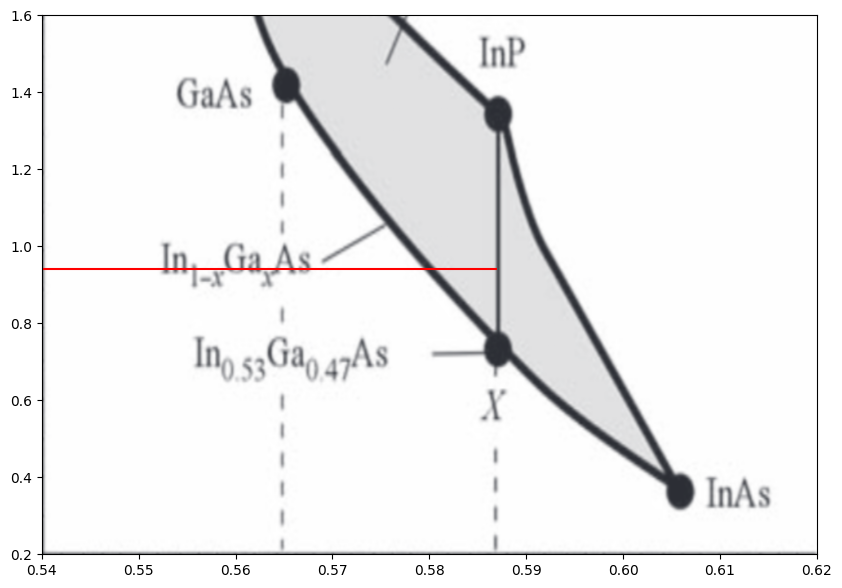

In [16]:
from scipy.constants import k

T = 300
wl = 1.3e-6
E_g = (h*c/wl - 0.5*k*T)/e # The correction term is necessary with bulk semiconductor lasers

img = plt.imread("lattice_matching_cropped.png")
fig, ax = plt.subplots(figsize=(10, 7))

ax.set_xlim([0.54, 0.62])
ax.set_ylim([0.2, 1.6])
ax.imshow(img, extent=[0.54, 0.62, 0.2, 1.6],aspect="auto")

ax.hlines(E_g, 0.54, 0.587, color="r", zorder=1)

Problem 3.19(b) in the textbook gives an empirical relation for the composition of the quaternary alloy $In_{1-x}Ga_{x}As_{1-y}P_{y}$ lattice matched to InP  

$$ E_g(eV) = 0.75 + 0.46y + 0.14y^2 $$

Problem 3.19(a) says  
$$ y = 1 - 2.13x $$

This implies that  
$$ x = \frac{1-y}{2.13} $$

We solve for y first, and then we backcalculate for x

In [17]:
_y = np.linspace(0, 1, 10000)
_E_g = np.polyval([0.14, 0.46, 0.75], _y)
i = np.argmin(np.abs(E_g - _E_g))
y = _y[i]
x = (1-y)/2.13

print(f"x = {x}")
print(f"y = {y}")

print(f"1-y = {1-y}")

print(f"In_{"{:.2f}".format(1-x)}Ga_{"{:.2f}".format(x)}As_{"{:.2f}".format(1-y)}P_{"{:.2f}".format(y)}")

x = 0.29458344895522415
y = 0.37253725372537255
1-y = 0.6274627462746274
In_0.71Ga_0.29As_0.63P_0.37


I will be using experimental data collected by Chandra et al. They use a different convention for their y values. My y value is equal to 1 -y for them. So I will find the refractive index corresponding to $y^{Chandra} = 1 - y$

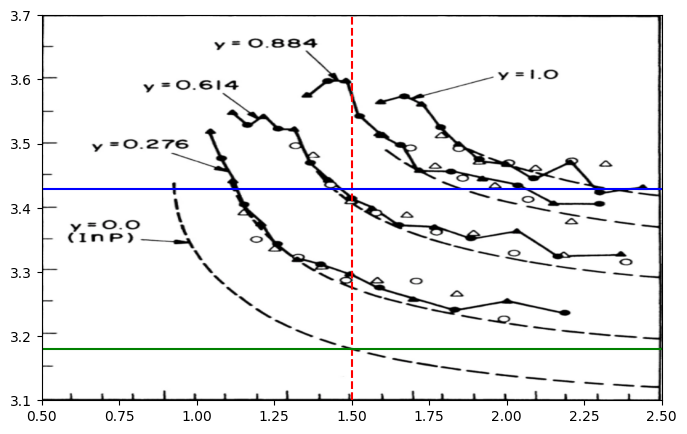

In [18]:
img = plt.imread("n_for_InGaAsP_cropped.png")
fig, ax = plt.subplots(figsize=(8, 5))

n2 = 3.18
n1 = 3.43

ax.set_xlim([0.5, 2.5])
ax.set_ylim([3.1, 3.7])
ax.imshow(img, extent=[0.5, 2.5, 3.1, 3.7],aspect="auto")
ax.vlines(1.5, 3.1, 3.7, color="red",linestyles=["--"])
ax.hlines([n1], 0.5, 2.5, color="blue")
ax.hlines([n2], 0.5, 2.5, color="green")

We calculate the V-number as:  
$$ V = kt \sqrt{n_1^2 - n_2^2} = \frac{2\pi}{\lambda}t \sqrt{n_1^2 - n_2^2} $$
$$ \Gamma = \frac{V^2}{2 + V^2} = \frac{k^2d^2(n_1^2 - n_2^2)}{2+k^2d^2(n_1^2 - n_2^2)} $$

In [19]:
def calculate_V_number(n1, n2, t, wl):
    return 2*np.pi/wl * t *np.sqrt(n1**2 - n2**2)

def calculate_confinement_factor(n1, n2, t, wl):
    V = calculate_V_number(n1, n2, t, wl)
    return V**2 / (2+V**2)

We will just pick sensible values for the thickness and doping and optimize them later on.

In [20]:
t = 1e-6
wl = 1.5e-6

Gamma = calculate_confinement_factor(n1, n2, t, wl)

print(f"Optical Confinement Factor: {Gamma}")

Optical Confinement Factor: 0.9354728482418885


For carrier confinement, 

This value is difficult to quantify, but the problem with poor carrier confinement is diffusion currrent   

$$ J_{th} = \frac{q n_{th} t}{\tau} + \frac{qD_e N_L}{L_e}exp(\frac{-(\Delta E_g - (E_Fn - E_C))}{kT})$$

Clearly, the second term goes to 0 with high $\Delta E_g$, thus, we have essentially limited our carriers to the active region by using a double heterojunction.  

To make a single mode laser, we will use a bragg grating to limit the operation to a single mode.

Starting with the Bragg Condition  
$$m(\frac{\lambda_B}{n}) = 2\Lambda$$
$$\Lambda = \frac{m}{2}(\frac{\lambda_B}{n})$$

In [21]:
m = 1

bragg_wl = wl

bragg_period = m/2 * bragg_wl / n1
print(bragg_period)

2.186588921282799e-07


This would work if we used bragg gratings as mirrors on either end, but instead, we wish to implement a distributed feedback laser

$$ \lambda_m = \lambda_B + \frac{\lambda_B^2}{2nL}(m+1) $$

Let $\lambda_m = \lambda_0$
$$ \lambda_0 = \lambda_B + \frac{\lambda_B^2}{2nL}(m+1) $$


We now solve for $\lambda_B$  

1.4969969969969969e-06
1.5e-06


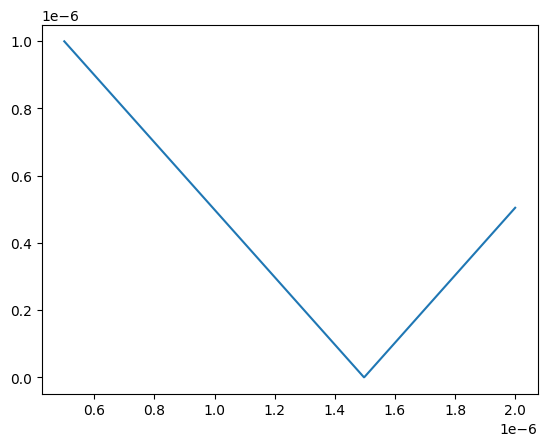

In [22]:
lam_B = np.linspace(0.5, 2.0, 1000)*1e-6
lam_m = wl
_lam_m = lam_B + lam_B**2 / (2*n1*L)*(m+1)
error = np.abs(lam_m - _lam_m)
plt.plot(lam_B, error)
lam_B = lam_B[np.argmin(error)]
# plt.plot(lam_B, _lam_m)
print(lam_B)
print(lam_m)

In [23]:
bragg_wl = lam_B

bragg_period = m/2 * bragg_wl / n1
print(bragg_period)

2.182211365884835e-07


### Final Design

Active Region Material: $In_{0.71}Ga_{0.29}As_{0.63}P_{0.37}$  
Active Region Thickness: $1 \mu m$ (gets 93.5% optical mode confinement)  
Bragg Grating Period (to enforce single mode condition): $0.2186 \mu m$

# 7.2

In order to find the desired bandgap for our quantum well laser to emit at 1.6 um, we need to realize that quantum well lasers emit primarily from $\epsilon_1$ above the conduction band to \epsilon_1^'$ below the conduction band.  

$$ \lambda \approx \frac{hc}{E_g + \epsilon_1 + \epsilon_1 '} $$

$$ \epsilon_1 = \frac{h^2 n^2}{8m_e^* d^2} = \frac{h^2}{8m_e^* d^2} = \epsilon_1'$$

$$ E_g \approx \frac{hc}{\lambda} - 2 \epsilon_1 $$
$$ E_g \approx \frac{hc}{\lambda} - \frac{h^2}{4m_e^* d^2} $$

Because we have the freedom to design our quantum well laser, we will choose a sensible value for the active layer region: 30nm  (note, this choice was not totally random, we had to pick a large enough value that the ideal bandgap was within the range of our quaternary alloys, while still picking an allow with a sufficiently larger refractive index than InP)

In [44]:
from scipy.constants import m_e
lam = 1.6e-6
m_star_e = 0.05*m_e
d = 30e-9

eps1 = (h**2 / (8*m_star_e * d**2))/e

E_g = (h*c/lam)/e - 2*eps1

print(eps1)
print(h*c/lam/e)
print(E_g)

0.008356225824552725
0.7749012402075017
0.7581887885583963


x = 0.46117287785116545
y = 0.0177017701770177
1-y = 0.9822982298229823
In_0.54Ga_0.46As_0.98P_0.02


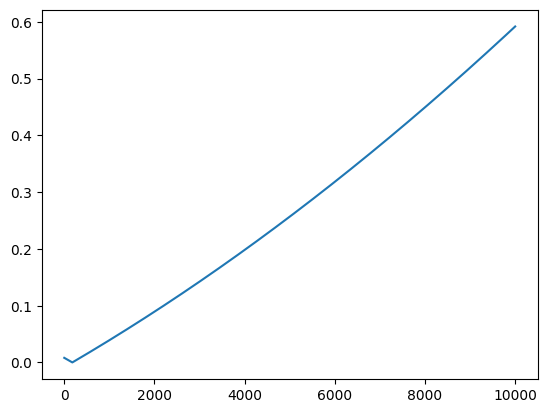

In [45]:
_y = np.linspace(0, 1, 10000)
_E_g = np.polyval([0.14, 0.46, 0.75], _y)
i = np.argmin(np.abs(E_g - _E_g))
y = _y[i]
x = (1-y)/2.13

plt.plot(np.abs(E_g - _E_g))

print(f"x = {x}")
print(f"y = {y}")

print(f"1-y = {1-y}")

print(f"In_{"{:.2f}".format(1-x)}Ga_{"{:.2f}".format(x)}As_{"{:.2f}".format(1-y)}P_{"{:.2f}".format(y)}")

# 7.3



Recall,for a given mode the emission frequency is
$$ \nu_m = \frac{mc}{2nL} $$
Where m is an integer indicating the mode number
$$ \lambda_m = \frac{c}{\nu_m} = \frac{2nL}{m} $$

If the refractive index changes by $\Delta n$  

$$ \lambda_m = \frac{2(n+\Delta n)L}{m} $$

$$ \lambda_m = \frac{2nL}{m} + \frac{2\Delta nL}{m} $$
$$ \Delta \lambda_m = \frac{2\Delta nL}{m} $$

In order to estimate $m$ for different wavelengths, we begin with the cavity condition:  
$$ m(\lambda_m/2) = L $$
$$ m = \frac{2L}{\lambda_m} $$

We will make the approximation that $\lambda_m \approx \lambda_0$, thus we can find the approximate mode number for a given emmission wavelength as  

$$ m = \frac{2L}{\lambda_0} $$

$$ \Delta \lambda = \frac{2\Delta nL \lambda_0}{2L} $$
$$ \Delta \lambda = \Delta n \lambda_0 $$

Text(0, 0.5, '$\\Delta \\lambda$ $pm$')

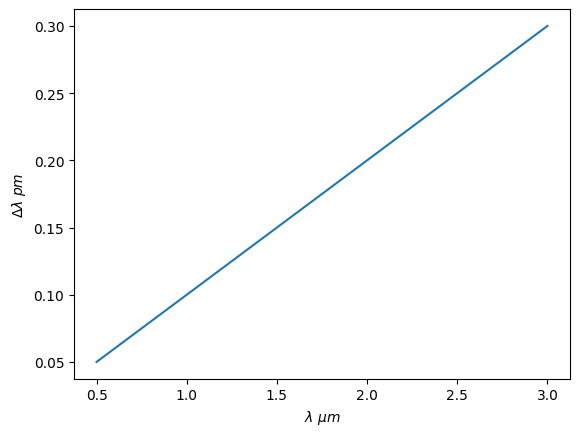

In [48]:
lam0 = np.linspace(0.5e-6, 3.0e-6)
delta_n = 1e-7
L = 1e-3

plt.plot(lam0 * 1e6, delta_n*lam0 * 1e12)

plt.xlabel(r"$\lambda$ $\mu m$")
plt.ylabel(r"$\Delta \lambda$ $pm$")